In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [44]:
data_df = pd.read_csv('../data/train.csv', index_col='PassengerId')

In [45]:
# Fill the data with sum miss value > 0
missing_data = data_df.isnull().sum()
print(missing_data[missing_data > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [46]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [47]:
target = 'Survived'

In [48]:
x = data_df.drop(columns=[target])
y = data_df[target]

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, train_size=0.8, random_state=1, stratify=y
)

In [50]:
# # học prefix hiếm từ train
# train_ticket_prefix = X_train['Ticket'].str.replace(r'[0-9./]', '', regex=True).str.strip()
# train_ticket_prefix = train_ticket_prefix.replace('', 'NONE')

# prefix_counts = train_ticket_prefix.value_counts()
# rare_prefixes = prefix_counts[prefix_counts < 10].index.tolist()

# # áp dụng cho train và test
# def make_ticket_prefix(ticket, rare_prefixes):
#     prefix = pd.Series([ticket]).str.replace(r'[0-9./]', '', regex=True).str.strip().iloc[0]
#     prefix = 'NONE' if prefix == '' else prefix
#     return 'RARE' if prefix in rare_prefixes else prefix

# X_train['TicketPrefix'] = X_train['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))
# X_test['TicketPrefix'] = X_test['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))

In [51]:
from sklearn.base import BaseEstimator, TransformerMixin
class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        group_cols=['Sex', 'Pclass'],
        target_col='Age'
    ):
        self.group_cols = group_cols
        self.target_col = target_col
        self.group_median_ = None
        self.global_median_ = None

    def fit(self, X, y=None):
        X = X.copy()

        # median theo nhóm
        self.group_median_ = (
            X.groupby(self.group_cols)[self.target_col]
            .median()
        )

        # median toàn cục
        self.global_median_ = X[self.target_col].median()

        return self

    def _fill_row(self, row):
        if pd.notna(row[self.target_col]):
            return row[self.target_col]

        key = tuple(row[col] for col in self.group_cols)

        if key in self.group_median_.index:
            val = self.group_median_.loc[key]
            if pd.notna(val):
                return val

        return self.global_median_

    def transform(self, X):
        X = X.copy()

        X[self.target_col] = X.apply(self._fill_row, axis=1)

        return X

In [52]:
# Title
X_train['Title'] = X_train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
X_test['Title'] = X_test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

for data in [X_train, X_test]:
    data['Title'] = data['Title'].replace(title_mapping)
    data['Title'] = data['Title'].replace(rare_titles, 'Rare')

In [53]:
X_train['Deck'] = X_train['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])
X_test['Deck'] = X_test['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])

In [54]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
cate_nor_feature = ['Sex', 'Embarked', 'Title', 'Deck']
cate_or_feature = ['Pclass']

In [55]:
age_imputer = AgeImputer()

X_train = age_imputer.fit_transform(X_train)
X_test = age_imputer.transform(X_test)


In [56]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

categorical_nor_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
categorical_or_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]]))
])
# Gộp preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat_nor', categorical_nor_transformer, cate_nor_feature),
    ('cat_ord',categorical_or_transformer, cate_or_feature)
]) 

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# 1. Khởi tạo Pipeline với SVM và bật chế độ cân bằng
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42))
])

# 2. Bộ siêu tham số chuyên dụng cho SVM
# C: Độ nghiêm khắc khi phân loại lỗi
# gamma: Mức độ chi tiết của đường ranh giới
param_grid_svm = {
    'model__C': [0.1, 1, 10, 50, 100],
    'model__gamma': ['scale', 'auto', 0.01, 0.1],
    'model__kernel': ['rbf', 'poly'] # RBF thường cho kết quả cực tốt
}

print("Đang dò tìm cấu hình tối ưu cho SVM... Vui lòng đợi.")

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, Y_train)

best_pipeline = grid_search_svm.best_estimator_
best_name = "SVM (Tuned for F1-Score)"

print(f"\n✅ Cấu hình xịn nhất của SVM là:\n{grid_search_svm.best_params_}")
print(f"Điểm Accuracy trung bình trên tập Train: {grid_search_svm.best_score_:.4f}")

Đang dò tìm cấu hình tối ưu cho SVM... Vui lòng đợi.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Cấu hình xịn nhất của SVM là:
{'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Điểm Accuracy trung bình trên tập Train: 0.8300


Best model: SVM (Tuned for F1-Score)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

Confusion Matrix:
[[99 11]
 [17 52]]


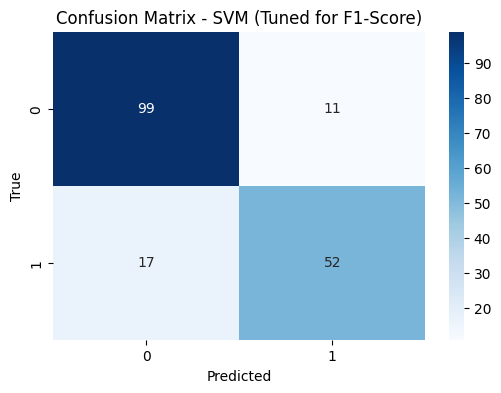

In [58]:
# ============================================
# Bước 5 - Đánh giá: classification_report, confusion_matrix
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dự đoán bằng pipeline tốt nhất
y_pred = best_pipeline.predict(X_test)

print(f"Best model: {best_name}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(Y_test, y_pred)
print(cm)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

In [59]:
# ============================================
# Bước 6 - Lưu mô hình (Pipeline)
# ============================================
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Lưu toàn bộ pipeline
joblib.dump(best_pipeline, '../models/titanic_model.joblib')
print("Đã lưu pipeline vào thư mục models/")

Đã lưu pipeline vào thư mục models/
